# This notebook will help you to do:
* Import training and test data
* Univariate Analysis
* Run many ML algorithms using H2O
* Compare all model performance in test dataset
* Choosing the best model

## The Digit Recognizer dataset will be used for this demonstration

# 1. Parameters

In [1]:
#Model ID
ModelId='digit_recognizer_FML_v1'

#Setting the model target variable name
var_target = 'label'

#process outputs such as MOJO model, images and performance of tested models
OutputPath='/kaggle/temp'

#If you have a huge dataset, I should consider use a small sample for first execution
pct_sample_size = 1

# 2. Import Libraries

In [2]:
import glob
import functools
import datetime as dt
import pandas as pd
import numpy as np
import h2o
import matplotlib.pyplot as plt
import shap
from pandas_profiling import ProfileReport
from collections import defaultdict
from pandas_profiling.model.base import get_var_type
import seaborn as sns
import os
import random

# 3. Importing Data for Modeling

In [3]:
#Import bases with features for modeling
#In this case we will use titanic dataset available below
dataprep_df_full = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
#The target variavle must be integer

dataprep_df_full['label'] = dataprep_df_full['label'].astype(int)

### It is necessary to create a variable to indicate the records used in training and testing. In this case we will use the random variable, but you can use a date variable for exemple if you have a base with a reference date to fix the training base as an out of time validation.

In [4]:
random.seed(59354518745)
for i in range(len(dataprep_df_full)):
    dataprep_df_full.loc[i, ('random')] = random.random()
dataprep_df_full['dataset'] = ['train' if x <= 0.85 else 'test' for x in dataprep_df_full['random']]
dataprep_df_full = dataprep_df_full.drop(labels=['random'], axis=1)

In [5]:
#Work with a sample data if the pct_sample_size is less than 1
if pct_sample_size == 1:
    dataprep_df = dataprep_df_full
else:    
    dataprep_df = dataprep_df_full.sample(frac=pct_sample_size, replace=False, random_state=1)

## 3.1 Feature Engineering

In [6]:
X_train = dataprep_df.drop(labels=[var_target, 'dataset'], axis=1)
X_train = X_train.astype('float32')
X_train = X_train / 255
dataprep_df = pd.concat([dataprep_df.loc[:,(var_target, 'dataset')], X_train], axis=1)

# 4. Univariate Analysis

## 4.1 Pandas Profiling

##### For more details on the pandas profiling library see https://github.com/pandas-profiling/pandas-profiling


In [7]:
#Generate report
#If the database has many records or columns, the report can take a long time
#If this is the case, disable the explorative, samples, correlations, missing_diagrams, duplicates and interactions options by commenting out
profile = ProfileReport(dataprep_df, title=f"Pandas Profiling Report{ModelId}"
                        ,explorative=True
                        ,samples=None
                        ,correlations=None
                        ,missing_diagrams=None
                        ,duplicates=None
                        ,interactions=None
                       )
#profile.to_file("profile.html")
#display(profile)

## 5. Classify the types of variables
#### list all columns to select the ones to be used

In [8]:
# Get all the types pandas_profiling offers
list_columns = dataprep_df.columns.drop('dataset').drop(var_target)
d = {col: get_var_type(dataprep_df[col])['type'].value for col in list_columns}
fd = defaultdict(list)
for k, v in d.items():
    fd[v].append(k)
     
cols_by_base_type = dict(fd)
# Group the types pandas_profiling offers to match typical needs
cat_num_cols = defaultdict(list)
for k, v in cols_by_base_type.items():
    # Treat boolean and unique columns as categorical
    k = 'CAT' if k in ['BOOL', 'UNIQUE'] else k
    cat_num_cols[k].extend(v)
#print(dict(cat_num_cols))

### From the variables listed above you can select which  one will be tested in the model and confirm if the correct type is numeric(NUM) or categorical (CAT). Paste the correct information below:

In [9]:
#It is necessary to define the types of variables (cageroric and numeric) to ensure that the type of data used in the modeling will be the most suitable.
#For example, categorical variables need to be defined as a string because this prevents it from being treated as a numeric variable in H20 modeling
#Another example is that the string variables will have a missing treatment by placing the missing category for all values found as 'null'
CAT = []
#float
NUM = cat_num_cols['NUM'] + cat_num_cols['CAT']

selected_features = CAT + NUM

In [10]:
#Numeric features must be float type
for col_name in NUM:    
    dataprep_df[col_name] = dataprep_df[col_name].astype(float)    

#Categorical features must be string type and null values will be filled with "missing"
for col_name in CAT:        
    dataprep_df[col_name] = dataprep_df[col_name].astype(str)
    dataprep_df = dataprep_df.fillna(value={col_name: 'missing'})    

# 6. Modeling

## 6.1 Creating context and H2O and Importing data into the H2O context

In [11]:
# Number of threads, nthreads = -1, means use all cores on your machine
# max_mem_size is the maximum memory (in GB) to allocate to H2O
h2o.init(nthreads = -1, max_mem_size = 8)

Checking whether there is an H2O instance running at http://localhost:54321 ..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.10" 2021-01-19; OpenJDK Runtime Environment (build 11.0.10+9-Ubuntu-0ubuntu1.18.04); OpenJDK 64-Bit Server VM (build 11.0.10+9-Ubuntu-0ubuntu1.18.04, mixed mode, sharing)
  Starting server from /opt/conda/lib/python3.7/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpj1ll5hvu
  JVM stdout: /tmp/tmpj1ll5hvu/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpj1ll5hvu/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.32.1.1
H2O_cluster_version_age:,8 days
H2O_cluster_name:,H2O_from_python_unknownUser_m0ncau
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"accepting new members, healthy"


In [12]:
#Import TRAINING base to the H20 context
data_hdf = h2o.H2OFrame(dataprep_df.query('dataset == "train"'))

# Conversion of Target variables and categorical features to factor (enum)
#no H2O it is necessary that the categorical variables are transformed into a factor
data_hdf[var_target] = data_hdf[var_target].asfactor()
for col_name in CAT:
    data_hdf[col_name] = data_hdf[col_name].asfactor()    
    
# Partition data into 90%, 10% chunks
# Setting a seed will guarantee reproducibility
train_hdf, valid_hdf = data_hdf.split_frame(ratios=[0.90], destination_frames=['train_hdf', 'valid_hdf'], seed=1)
        
#Notice that `split_frame()` uses approximate splitting not exact splitting (for efficiency), so these are not exactly 90%, 10% of the total rows.
print('Training: ' + str(train_hdf.nrow))
print('Validation: ' + str(valid_hdf.nrow))

Parse progress: |█████████████████████████████████████████████████████████| 100%
Training: 31962
Validation: 3618


In [13]:
#Import TEST base to the H20 context
test_hdf = h2o.H2OFrame(dataprep_df.query('dataset == "test"'))

# Conversion of Target variables and categorical features to factor (enum)
#no H2O it is necessary that the categorical variables are transformed into a factor
test_hdf[var_target] = test_hdf[var_target].asfactor()
for col_name in CAT:
    test_hdf[col_name] = test_hdf[col_name].asfactor()    
    
print('Test: ' + str(test_hdf.nrow))

Parse progress: |█████████████████████████████████████████████████████████| 100%
Test: 6420


## 6.2 Using H2O to performe many ML algorithms

## Logistic Regresion (GLM)

In [14]:
vModel = 'GLM_'

start = dt.datetime.now()
from h2o.estimators.glm import H2OGeneralizedLinearEstimator

#definir parámetros
GLM = H2OGeneralizedLinearEstimator(family= 'multinomial',
                                    seed=1,
                                    #auc_type="MACRO_OVR",
                                    model_id='%s%s%s' % (vModel, ModelId, str(dt.datetime.now())[:19].replace('-',"").replace(':',"").replace(' ',"_")))

#Executar Modelo
GLM.train(x = selected_features,
          y = var_target,
          training_frame = train_hdf,
          validation_frame = valid_hdf)

#Execution time of the model
stop = dt.datetime.now()
execution_time = stop-start
print("\n"+ "Execution time: " + str(execution_time) +"\n")
print(GLM)

Dropping bad and constant columns: [pixel729, pixel644, pixel645, pixel448, pixel726, pixel727, pixel728, pixel560, pixel52, pixel760, pixel10, pixel54, pixel761, pixel53, pixel168, pixel56, pixel11, pixel55, pixel57, pixel16, pixel59, pixel18, pixel17, pixel19, pixel754, pixel755, pixel756, pixel559, pixel757, pixel758, pixel759, pixel83, pixel196, pixel82, pixel85, pixel671, pixel84, pixel111, pixel672, pixel112, pixel673, pixel113, pixel476, pixel114, pixel477, pixel392, pixel700, pixel701, pixel141, pixel780, pixel30, pixel781, pixel782, pixel420, pixel783, pixel31, pixel421, pixel588, pixel140, pixel699, pixel139, pixel8, pixel9, pixel616, pixel6, pixel7, pixel4, pixel5, pixel2, pixel3, pixel0, pixel21, pixel1, pixel20, pixel23, pixel532, pixel730, pixel22, pixel731, pixel25, pixel24, pixel27, pixel26, pixel29, pixel28]


glm Model Build progress: |███████████████████████████████████████████████| 100%


Reached maximum number of iterations 50!



Execution time: 0:00:15.702288

Model Details
H2OGeneralizedLinearEstimator :  Generalized Linear Modeling
Model Key:  GLM_digit_recognizer_FML_v120210403_145445


GLM Model: summary


,,family,link,regularization,number_of_predictors_total,number_of_active_predictors,number_of_iterations,training_frame
0,,multinomial,multinomial,"Elastic Net (alpha = 0.5, lambda = 3.318E-4 )",7000,6990,50,train_hdf




ModelMetricsMultinomialGLM: glm
** Reported on train data. **

MSE: 0.057475600734222046
RMSE: 0.23974069478130333

ModelMetricsMultinomialGLM: glm
** Reported on validation data. **

MSE: 0.07513091171101789
RMSE: 0.27410018553627047

Scoring History: 


,,timestamp,duration,iterations,negative_log_likelihood,objective,training_rmse,training_logloss,training_r2,training_classification_error,training_auc,training_pr_auc,validation_rmse,validation_logloss,validation_r2,validation_classification_error,validation_auc,validation_pr_auc
0,,2021-04-03 14:54:46,0.000 sec,0,73548.262676,2.301116,,,,,,,,,,,,
1,,2021-04-03 14:54:47,0.983 sec,1,31431.521770,1.011435,,,,,,,,,,,,
2,,2021-04-03 14:54:48,1.294 sec,2,16310.465233,0.540755,,,,,,,,,,,,
3,,2021-04-03 14:54:48,1.450 sec,3,13581.108728,0.455242,,,,,,,,,,,,
4,,2021-04-03 14:54:48,1.757 sec,4,11896.966913,0.402450,,,,,,,,,,,,
5,,2021-04-03 14:54:48,2.052 sec,5,10878.600718,0.370444,,,,,,,,,,,,
6,,2021-04-03 14:54:49,2.378 sec,6,10258.354347,0.351548,,,,,,,,,,,,
7,,2021-04-03 14:54:49,2.699 sec,7,9780.548030,0.337622,,,,,,,,,,,,
8,,2021-04-03 14:54:49,3.008 sec,8,9369.459755,0.326828,,,,,,,,,,,,
9,,2021-04-03 14:54:50,3.303 sec,9,8973.423735,0.317532,,,,,,,,,,,,



See the whole table with table.as_data_frame()

Variable Importances: 


,variable,relative_importance,scaled_importance,percentage
0,pixel322,1.384308,1.000000,0.004378
1,pixel379,1.327530,0.958985,0.004199
2,pixel351,1.324122,0.956523,0.004188
3,pixel350,1.212282,0.875732,0.003834
4,pixel323,1.203146,0.869132,0.003805
5,pixel325,1.176730,0.850050,0.003722
6,pixel376,1.174096,0.848147,0.003714
7,pixel377,1.157391,0.836079,0.003661
8,pixel461,1.140347,0.823767,0.003607
9,pixel570,1.131564,0.817422,0.003579



See the whole table with table.as_data_frame()



## GBM - Gradient Boosting Machine

In [15]:
vModel='GBM_'

#Execution time of the model
start = dt.datetime.now()

from h2o.estimators.gbm import H2OGradientBoostingEstimator
GBM = H2OGradientBoostingEstimator(model_id='%s%s%s' % (vModel, ModelId, str(dt.datetime.now())[:19].replace('-',"").replace(':',"").replace(' ',"_")),
                                   ntrees=500,
                                   score_tree_interval=5,     #used for early stopping
                                   stopping_rounds=3,         #used for early stopping
                                   stopping_metric='mean_per_class_error',     #used for early stopping
                                   stopping_tolerance=0.0005, #used for early stopping
                                   #auc_type="MACRO_OVR",
                                   seed=1)

# The use of a validation_frame is recommended with using early stopping
GBM.train(x=selected_features, y=var_target, training_frame=train_hdf, validation_frame=valid_hdf)

#Execution time of the model
stop = dt.datetime.now()
execution_time = stop-start
print("\n"+ "Execution time: " + str(execution_time) + "\n")
print(GBM)

Dropping bad and constant columns: [pixel729, pixel644, pixel645, pixel448, pixel726, pixel727, pixel728, pixel560, pixel52, pixel760, pixel10, pixel54, pixel761, pixel53, pixel168, pixel56, pixel11, pixel55, pixel57, pixel16, pixel59, pixel18, pixel17, pixel19, pixel754, pixel755, pixel756, pixel559, pixel757, pixel758, pixel759, pixel83, pixel196, pixel82, pixel85, pixel671, pixel84, pixel111, pixel672, pixel112, pixel673, pixel113, pixel476, pixel114, pixel477, pixel392, pixel700, pixel701, pixel141, pixel780, pixel30, pixel781, pixel782, pixel420, pixel783, pixel31, pixel421, pixel588, pixel140, pixel699, pixel139, pixel8, pixel9, pixel616, pixel6, pixel7, pixel4, pixel5, pixel2, pixel3, pixel0, pixel21, pixel1, pixel20, pixel23, pixel532, pixel730, pixel22, pixel731, pixel25, pixel24, pixel27, pixel26, pixel29, pixel28]


gbm Model Build progress: |███████████████████████████████████████████████| 100%

Execution time: 0:25:45.671545

Model Details
H2OGradientBoostingEstimator :  Gradient Boosting Machine
Model Key:  GBM_digit_recognizer_FML_v120210403_145502


Model Summary: 


,,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
0,,225.0,2250.0,867662.0,5.0,5.0,5.0,9.0,32.0,25.896




ModelMetricsMultinomial: gbm
** Reported on train data. **

MSE: 1.4402953758649946e-05
RMSE: 0.0037951223641208127
LogLoss: 0.0013794105112355675
Mean Per-Class Error: 0.0
AUC: NaN
AUCPR: NaN
Multinomial auc values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).
Multinomial auc_pr values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class


,0,1,2,3,4,5,6,7,8,9,Error,Rate
0,3118.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"0 / 3,118"
1,0.0,3568.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"0 / 3,568"
2,0.0,0.0,3197.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"0 / 3,197"
3,0.0,0.0,0.0,3286.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"0 / 3,286"
4,0.0,0.0,0.0,0.0,3112.0,0.0,0.0,0.0,0.0,0.0,0.0,"0 / 3,112"
5,0.0,0.0,0.0,0.0,0.0,2875.0,0.0,0.0,0.0,0.0,0.0,"0 / 2,875"
6,0.0,0.0,0.0,0.0,0.0,0.0,3150.0,0.0,0.0,0.0,0.0,"0 / 3,150"
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3362.0,0.0,0.0,0.0,"0 / 3,362"
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3098.0,0.0,0.0,"0 / 3,098"
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3196.0,0.0,"0 / 3,196"


...


Scoring History: 


,,timestamp,duration,number_of_trees,training_rmse,training_logloss,training_classification_error,training_auc,training_pr_auc,validation_rmse,validation_logloss,validation_classification_error,validation_auc,validation_pr_auc
0,,2021-04-03 14:55:02,0.047 sec,0.0,0.900000,2.302585,0.900194,NaN,NaN,0.900000,2.302585,0.901879,NaN,NaN
1,,2021-04-03 14:55:42,40.511 sec,5.0,0.605342,0.992267,0.114010,NaN,NaN,0.613144,1.020613,0.134052,NaN,NaN
2,,2021-04-03 14:56:21,1 min 18.604 sec,10.0,0.440655,0.602451,0.082379,NaN,NaN,0.460115,0.649798,0.103096,NaN,NaN
3,,2021-04-03 14:56:58,1 min 56.144 sec,15.0,0.346965,0.404361,0.063826,NaN,NaN,0.376326,0.462708,0.092040,NaN,NaN
4,,2021-04-03 14:57:34,2 min 31.692 sec,20.0,0.289807,0.291865,0.051436,NaN,NaN,0.327601,0.357779,0.079326,NaN,NaN
5,,2021-04-03 14:58:09,3 min 6.664 sec,25.0,0.249869,0.221998,0.040892,NaN,NaN,0.295063,0.292964,0.068270,NaN,NaN
6,,2021-04-03 14:58:42,3 min 40.413 sec,30.0,0.218277,0.172978,0.032507,NaN,NaN,0.270622,0.248041,0.060254,NaN,NaN
7,,2021-04-03 14:59:16,4 min 14.037 sec,35.0,0.195051,0.140895,0.026500,NaN,NaN,0.254772,0.219863,0.057767,NaN,NaN
8,,2021-04-03 14:59:51,4 min 48.644 sec,40.0,0.173332,0.114549,0.020462,NaN,NaN,0.242187,0.198820,0.053344,NaN,NaN
9,,2021-04-03 15:00:28,5 min 26.297 sec,45.0,0.156672,0.096147,0.016019,NaN,NaN,0.232916,0.183618,0.050028,NaN,NaN



See the whole table with table.as_data_frame()

Variable Importances: 


,variable,relative_importance,scaled_importance,percentage
0,pixel437,2462.873291,1.000000,0.024365
1,pixel406,2330.952881,0.946436,0.023060
2,pixel435,2158.465088,0.876401,0.021353
3,pixel489,2123.561279,0.862229,0.021008
4,pixel358,2076.432373,0.843093,0.020542
5,pixel211,2070.099854,0.840522,0.020479
6,pixel100,1795.108276,0.728867,0.017759
7,pixel386,1488.191162,0.604250,0.014722
8,pixel243,1479.895508,0.600882,0.014640
9,pixel432,1388.934692,0.563949,0.013741



See the whole table with table.as_data_frame()



## GBM - Gradient Boosting Machine with Cross-Validation

In [16]:
vModel='GBM_cv_'

#Execution time of the model
start = dt.datetime.now()

from h2o.estimators.gbm import H2OGradientBoostingEstimator
GBM_cv = H2OGradientBoostingEstimator(model_id='%s%s%s' % (vModel, ModelId, str(dt.datetime.now())[:19].replace('-',"").replace(':',"").replace(' ',"_"))
                                   ,nfolds=5
                                   ,seed=1
                                   #,auc_type="MACRO_OVR"
                                   )

# The use of a validation_frame is recommended with using early stopping
GBM_cv.train(x=selected_features, y=var_target, training_frame=train_hdf, validation_frame=valid_hdf)

#Execution time of the model
stop = dt.datetime.now()
execution_time = stop-start
print("\n"+ "Execution time: " + str(execution_time) + "\n")
print(GBM_cv)

Dropping bad and constant columns: [pixel729, pixel644, pixel645, pixel448, pixel726, pixel727, pixel728, pixel560, pixel52, pixel760, pixel10, pixel54, pixel761, pixel53, pixel168, pixel56, pixel11, pixel55, pixel57, pixel16, pixel59, pixel18, pixel17, pixel19, pixel754, pixel755, pixel756, pixel559, pixel757, pixel758, pixel759, pixel83, pixel196, pixel82, pixel85, pixel671, pixel84, pixel111, pixel672, pixel112, pixel673, pixel113, pixel476, pixel114, pixel477, pixel392, pixel700, pixel701, pixel141, pixel780, pixel30, pixel781, pixel782, pixel420, pixel783, pixel31, pixel421, pixel588, pixel140, pixel699, pixel139, pixel8, pixel9, pixel616, pixel6, pixel7, pixel4, pixel5, pixel2, pixel3, pixel0, pixel21, pixel1, pixel20, pixel23, pixel532, pixel730, pixel22, pixel731, pixel25, pixel24, pixel27, pixel26, pixel29, pixel28]


gbm Model Build progress: |███████████████████████████████████████████████| 100%

Execution time: 0:30:29.560737

Model Details
H2OGradientBoostingEstimator :  Gradient Boosting Machine
Model Key:  GBM_cv_digit_recognizer_FML_v120210403_152048


Model Summary: 


,,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
0,,50.0,500.0,207818.0,5.0,5.0,5.0,15.0,32.0,28.348




ModelMetricsMultinomial: gbm
** Reported on train data. **

MSE: 0.02006785986950626
RMSE: 0.1416610739388427
LogLoss: 0.08132569081122493
Mean Per-Class Error: 0.012847951713299596
AUC: NaN
AUCPR: NaN
Multinomial auc values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).
Multinomial auc_pr values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class


,0,1,2,3,4,5,6,7,8,9,Error,Rate
0,3111.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0,0.0,0.002245,"7 / 3,118"
1,0.0,3562.0,1.0,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.001682,"6 / 3,568"
2,1.0,2.0,3154.0,9.0,7.0,1.0,1.0,8.0,11.0,3.0,0.013450,"43 / 3,197"
3,2.0,0.0,19.0,3215.0,0.0,16.0,1.0,10.0,13.0,10.0,0.021607,"71 / 3,286"
4,0.0,3.0,0.0,0.0,3074.0,0.0,3.0,2.0,1.0,29.0,0.012211,"38 / 3,112"
5,2.0,1.0,5.0,9.0,2.0,2841.0,7.0,0.0,4.0,4.0,0.011826,"34 / 2,875"
6,2.0,1.0,0.0,0.0,5.0,10.0,3125.0,0.0,7.0,0.0,0.007937,"25 / 3,150"
7,0.0,3.0,15.0,4.0,2.0,0.0,0.0,3311.0,2.0,25.0,0.015170,"51 / 3,362"
8,1.0,4.0,4.0,7.0,3.0,2.0,5.0,1.0,3055.0,16.0,0.013880,"43 / 3,098"
9,4.0,5.0,1.0,20.0,17.0,8.0,2.0,26.0,8.0,3105.0,0.028473,"91 / 3,196"


...


Scoring History: 


,,timestamp,duration,number_of_trees,training_rmse,training_logloss,training_classification_error,training_auc,training_pr_auc,validation_rmse,validation_logloss,validation_classification_error,validation_auc,validation_pr_auc
0,,2021-04-03 15:45:38,24 min 49.328 sec,0.0,0.900000,2.302585,0.900194,NaN,NaN,0.900000,2.302585,0.901879,NaN,NaN
1,,2021-04-03 15:45:45,24 min 56.216 sec,1.0,0.818224,1.738073,0.166010,NaN,NaN,0.819237,1.745801,0.181592,NaN,NaN
2,,2021-04-03 15:45:51,25 min 2.903 sec,2.0,0.754789,1.457172,0.140573,NaN,NaN,0.757134,1.470643,0.156440,NaN,NaN
3,,2021-04-03 15:45:58,25 min 9.516 sec,3.0,0.699636,1.264478,0.129247,NaN,NaN,0.703561,1.283734,0.147043,NaN,NaN
4,,2021-04-03 15:46:05,25 min 16.537 sec,4.0,0.649547,1.112871,0.121488,NaN,NaN,0.655392,1.136854,0.138751,NaN,NaN
5,,2021-04-03 15:46:12,25 min 23.250 sec,5.0,0.605342,0.992267,0.114010,NaN,NaN,0.613144,1.020613,0.134052,NaN,NaN
6,,2021-04-03 15:46:19,25 min 30.363 sec,6.0,0.564733,0.888680,0.105876,NaN,NaN,0.574525,0.920866,0.125760,NaN,NaN
7,,2021-04-03 15:46:25,25 min 37.034 sec,7.0,0.529031,0.802898,0.099962,NaN,NaN,0.541208,0.839359,0.120232,NaN,NaN
8,,2021-04-03 15:46:32,25 min 43.663 sec,8.0,0.496040,0.726083,0.093017,NaN,NaN,0.510575,0.766282,0.112769,NaN,NaN
9,,2021-04-03 15:46:39,25 min 50.771 sec,9.0,0.466411,0.658891,0.086478,NaN,NaN,0.483362,0.702911,0.107518,NaN,NaN



See the whole table with table.as_data_frame()

Variable Importances: 


,variable,relative_importance,scaled_importance,percentage
0,pixel437,2461.166992,1.000000,0.024506
1,pixel406,2327.806396,0.945814,0.023178
2,pixel435,2156.633057,0.876264,0.021474
3,pixel489,2121.730469,0.862083,0.021127
4,pixel358,2076.205322,0.843586,0.020673
5,pixel211,2067.564453,0.840075,0.020587
6,pixel100,1793.519287,0.728727,0.017858
7,pixel386,1487.817383,0.604517,0.014815
8,pixel243,1478.650024,0.600792,0.014723
9,pixel432,1386.246826,0.563248,0.013803



See the whole table with table.as_data_frame()



## Random Forest

In [17]:
vModel='DRF_CV_'

#Execution time of the model
start = dt.datetime.now()

from h2o.estimators.random_forest import H2ORandomForestEstimator

DRF = H2ORandomForestEstimator(seed=1
                               ,nfolds=5
                               #,auc_type="MACRO_OVR"
                               ,model_id='%s%s%s' % (vModel, ModelId, str(dt.datetime.now())[:19].replace('-',"").replace(':',"").replace(' ',"_")))

# The use of a validation_frame is recommended with using early stopping
DRF.train(x=selected_features, y=var_target, training_frame=train_hdf, validation_frame=valid_hdf)

#Execution time of the model
stop = dt.datetime.now()
execution_time = stop-start
print("\n"+ "Execution time: " + str(execution_time) + "\n")
print(DRF)

Dropping bad and constant columns: [pixel729, pixel644, pixel645, pixel448, pixel726, pixel727, pixel728, pixel560, pixel52, pixel760, pixel10, pixel54, pixel761, pixel53, pixel168, pixel56, pixel11, pixel55, pixel57, pixel16, pixel59, pixel18, pixel17, pixel19, pixel754, pixel755, pixel756, pixel559, pixel757, pixel758, pixel759, pixel83, pixel196, pixel82, pixel85, pixel671, pixel84, pixel111, pixel672, pixel112, pixel673, pixel113, pixel476, pixel114, pixel477, pixel392, pixel700, pixel701, pixel141, pixel780, pixel30, pixel781, pixel782, pixel420, pixel783, pixel31, pixel421, pixel588, pixel140, pixel699, pixel139, pixel8, pixel9, pixel616, pixel6, pixel7, pixel4, pixel5, pixel2, pixel3, pixel0, pixel21, pixel1, pixel20, pixel23, pixel532, pixel730, pixel22, pixel731, pixel25, pixel24, pixel27, pixel26, pixel29, pixel28]


drf Model Build progress: |███████████████████████████████████████████████| 100%

Execution time: 0:27:50.399608

Model Details
H2ORandomForestEstimator :  Distributed Random Forest
Model Key:  DRF_CV_digit_recognizer_FML_v120210403_155119


Model Summary: 


,,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
0,,50.0,500.0,3796441.0,14.0,20.0,19.336,239.0,931.0,598.292




ModelMetricsMultinomial: drf
** Reported on train data. **

MSE: 0.07767571138171092
RMSE: 0.27870362642368135
LogLoss: 0.3527761804420157
Mean Per-Class Error: 0.04333521107131105
AUC: NaN
AUCPR: NaN
Multinomial auc values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).
Multinomial auc_pr values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class


,0,1,2,3,4,5,6,7,8,9,Error,Rate
0,3057.0,0.0,5.0,2.0,7.0,3.0,19.0,3.0,21.0,1.0,0.019564,"61 / 3,118"
1,1.0,3500.0,19.0,6.0,6.0,4.0,12.0,7.0,7.0,6.0,0.019058,"68 / 3,568"
2,9.0,5.0,3077.0,20.0,15.0,3.0,6.0,23.0,35.0,4.0,0.037535,"120 / 3,197"
3,3.0,6.0,57.0,3068.0,1.0,36.0,12.0,28.0,45.0,30.0,0.066342,"218 / 3,286"
4,6.0,5.0,10.0,0.0,2971.0,0.0,17.0,7.0,13.0,83.0,0.045308,"141 / 3,112"
5,16.0,1.0,8.0,40.0,8.0,2721.0,39.0,3.0,21.0,18.0,0.053565,"154 / 2,875"
6,15.0,1.0,3.0,0.0,10.0,26.0,3075.0,0.0,19.0,1.0,0.023810,"75 / 3,150"
7,1.0,18.0,38.0,4.0,15.0,1.0,0.0,3208.0,11.0,66.0,0.045806,"154 / 3,362"
8,10.0,18.0,27.0,38.0,16.0,30.0,16.0,5.0,2906.0,32.0,0.061975,"192 / 3,098"
9,11.0,7.0,10.0,34.0,43.0,13.0,3.0,42.0,30.0,3003.0,0.060388,"193 / 3,196"


...


Scoring History: 


,,timestamp,duration,number_of_trees,training_rmse,training_logloss,training_classification_error,training_auc,training_pr_auc,validation_rmse,validation_logloss,validation_classification_error,validation_auc,validation_pr_auc
0,,2021-04-03 16:14:16,22 min 56.701 sec,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,2021-04-03 16:14:22,23 min 2.386 sec,1.0,0.458391,6.284830,0.260583,NaN,NaN,0.472839,6.713567,0.274461,NaN,NaN
2,,2021-04-03 16:14:28,23 min 8.347 sec,2.0,0.439903,5.565248,0.234090,NaN,NaN,0.367612,3.023899,0.160310,NaN,NaN
3,,2021-04-03 16:14:33,23 min 14.147 sec,3.0,0.422855,4.902287,0.214800,NaN,NaN,0.324926,1.686677,0.117745,NaN,NaN
4,,2021-04-03 16:14:39,23 min 19.726 sec,4.0,0.404286,4.273707,0.192090,NaN,NaN,0.302707,1.082549,0.095357,NaN,NaN
5,,2021-04-03 16:14:45,23 min 25.297 sec,5.0,0.388084,3.712736,0.173208,NaN,NaN,0.293954,0.800296,0.080708,NaN,NaN
6,,2021-04-03 16:14:50,23 min 31.014 sec,6.0,0.372877,3.194402,0.154664,NaN,NaN,0.291354,0.618272,0.074903,NaN,NaN
7,,2021-04-03 16:14:56,23 min 36.448 sec,7.0,0.359439,2.772411,0.140337,NaN,NaN,0.287211,0.518167,0.066059,NaN,NaN
8,,2021-04-03 16:15:02,23 min 42.421 sec,8.0,0.347223,2.381004,0.127242,NaN,NaN,0.285741,0.464699,0.061360,NaN,NaN
9,,2021-04-03 16:15:07,23 min 48.023 sec,9.0,0.338325,2.094312,0.116419,NaN,NaN,0.284349,0.429096,0.056385,NaN,NaN



See the whole table with table.as_data_frame()

Variable Importances: 


,variable,relative_importance,scaled_importance,percentage
0,pixel406,11247.171875,1.000000,0.011785
1,pixel350,9107.929688,0.809797,0.009543
2,pixel434,8896.480469,0.790997,0.009322
3,pixel437,7255.241699,0.645073,0.007602
4,pixel211,6858.128906,0.609765,0.007186
5,pixel435,6518.443359,0.579563,0.006830
6,pixel489,6396.255859,0.568699,0.006702
7,pixel378,5799.305664,0.515623,0.006077
8,pixel487,5620.292480,0.499707,0.005889
9,pixel322,5595.426758,0.497496,0.005863



See the whole table with table.as_data_frame()



## H2OAutoML

In [18]:
vModel='AUTOML'

#Execution time of the model
start = dt.datetime.now()

#Set the maximum time in seconds for the H20 AutoML
max_runtime_secs=60*10

#Define metrics to select the best model in AutoML
sort_metric = 'mean_per_class_error'

from h2o.automl import H2OAutoML
AUTOML = H2OAutoML(seed=1,                   
                   include_algos = ['DRF', 'GLM', 'XGBoost', 'GBM', 'DeepLearning', 'StackedEnsemble'],
                   max_runtime_secs = max_runtime_secs,
                   stopping_metric = sort_metric,
                   sort_metric = sort_metric)
AUTOML.train(x=selected_features, y=var_target, training_frame = train_hdf, validation_frame = valid_hdf, leaderboard_frame=test_hdf)

#View the AutoML Leaderboard
lb = AUTOML.leaderboard
print(lb.head(rows=lb.nrows))

#Execution time of the model
stop = dt.datetime.now()
execution_time = stop-start
print("\n"+ "Execution time: " + str(execution_time) + "\n")

AutoML progress: |
16:19:12.185: User specified a validation frame with cross-validation still enabled. Please note that the models will still be validated using cross-validation only, the validation frame will be used to provide purely informative validation metrics on the trained models.

████████████████████████████████████████████████████████| 100%


model_id,mean_per_class_error,logloss,rmse,mse,auc,aucpr
XGBoost_1_AutoML_20210403_161912,0.136801,1.34402,0.722129,0.52147,nan,nan
XGBoost_2_AutoML_20210403_161912,0.148166,1.37566,0.730714,0.533943,nan,nan
XGBoost_3_AutoML_20210403_161912,0.194341,1.46969,0.751578,0.56487,nan,nan
GLM_1_AutoML_20210403_161912,0.322967,1.90051,0.84615,0.71597,nan,nan
StackedEnsemble_AllModels_AutoML_20210403_161912,0.890131,7.41632,0.935177,0.874556,nan,nan
StackedEnsemble_BestOfFamily_AutoML_20210403_161912,0.9,16.3573,0.94819,0.899065,nan,nan




Execution time: 1:09:19.170334



In [19]:
#Choose the desired AutoML model
best_automl_position=0
if len(AUTOML.leaderboard) > 0:
    best_AutoML = h2o.get_model(AUTOML.leaderboard[best_automl_position, 0])
    print(best_AutoML)

Model Details
H2OXGBoostEstimator :  XGBoost
Model Key:  XGBoost_1_AutoML_20210403_161912


Model Summary: 


,,number_of_trees
0,,1.0




ModelMetricsMultinomial: xgboost
** Reported on train data. **

MSE: 0.5120075919453709
RMSE: 0.7155470578133705
LogLoss: 1.3103643561152047
Mean Per-Class Error: 0.10884943725516463
AUC: NaN
AUCPR: NaN
Multinomial auc values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).
Multinomial auc_pr values: Table is not computed because it is disabled (model parameter 'auc_type' is set to AUTO or NONE) or due to domain size (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class


,0,1,2,3,4,5,6,7,8,9,Error,Rate
0,2970.0,1.0,20.0,16.0,23.0,25.0,13.0,9.0,40.0,1.0,0.047466,"148 / 3,118"
1,1.0,3414.0,34.0,29.0,15.0,8.0,23.0,11.0,31.0,2.0,0.043161,"154 / 3,568"
2,30.0,44.0,2735.0,89.0,61.0,9.0,48.0,36.0,123.0,22.0,0.144510,"462 / 3,197"
3,21.0,24.0,102.0,2841.0,15.0,85.0,20.0,49.0,82.0,47.0,0.135423,"445 / 3,286"
4,17.0,11.0,24.0,18.0,2818.0,24.0,31.0,29.0,37.0,103.0,0.094473,"294 / 3,112"
5,39.0,16.0,27.0,78.0,39.0,2516.0,56.0,19.0,54.0,31.0,0.124870,"359 / 2,875"
6,41.0,7.0,25.0,10.0,49.0,77.0,2878.0,3.0,59.0,1.0,0.086349,"272 / 3,150"
7,13.0,37.0,51.0,39.0,30.0,21.0,9.0,2982.0,44.0,136.0,0.113028,"380 / 3,362"
8,26.0,73.0,64.0,68.0,41.0,59.0,21.0,25.0,2678.0,43.0,0.135571,"420 / 3,098"
9,29.0,18.0,50.0,69.0,101.0,32.0,6.0,181.0,37.0,2673.0,0.163642,"523 / 3,196"



Top-10 Hit Ratios: 


...


Scoring History: 


,,timestamp,duration,number_of_trees,training_rmse,training_logloss,training_classification_error,training_auc,training_pr_auc,validation_rmse,validation_logloss,validation_classification_error,validation_auc,validation_pr_auc
0,,2021-04-03 16:19:40,27.999 sec,0.0,0.900000,2.302585,0.894813,NaN,NaN,0.900000,2.302585,0.899668,NaN,NaN
1,,2021-04-03 16:19:45,33.036 sec,1.0,0.715547,1.310364,0.108160,NaN,NaN,0.722342,1.343902,0.137645,NaN,NaN



Variable Importances: 


,variable,relative_importance,scaled_importance,percentage
0,pixel378,2971.372314,1.000000,0.040579
1,pixel358,2657.085938,0.894229,0.036286
2,pixel100,2296.621094,0.772916,0.031364
3,pixel435,2257.810547,0.759854,0.030834
4,pixel437,2233.544922,0.751688,0.030502
5,pixel740,1960.849243,0.659914,0.026778
6,pixel403,1885.183350,0.634449,0.025745
7,pixel487,1726.695435,0.581110,0.023581
8,pixel656,1629.276855,0.548325,0.022250
9,pixel322,1543.403931,0.519425,0.021077



See the whole table with table.as_data_frame()



## 6.3 Compare performance on the TEST dataset for all trained models

In [20]:
#Create empty model list
list_models = []

#Define the list of all models that have been executed and should be compared
try:
    list_models.append(GLM)
except NameError:
    GLM = None
try:
    list_models.append(GBM)
except NameError:
    GBM = None
try:
    list_models.append(GBM_cv)
except NameError:
    GBM_cv = None
try:
    list_models.append(DRF)
except NameError:
    DRF = None
try:
    list_models.append(best_AutoML)
except NameError:
    best_AutoML = None

<Figure size 720x720 with 0 Axes>

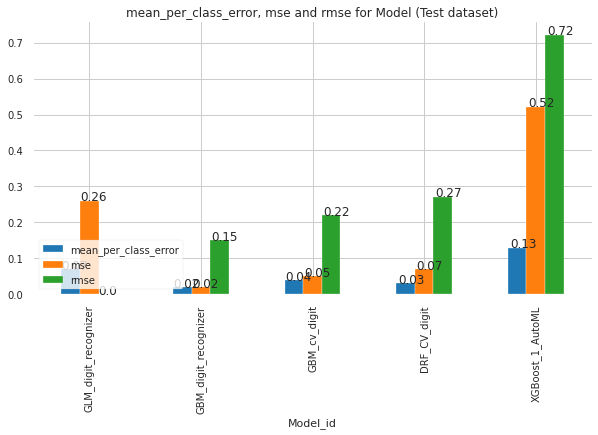

In [21]:
#Compare performance on the TEST dataset for all trained models
plt.rcParams.update({'font.size': 12})
fig = plt.figure(figsize=(10, 10))
for i in list_models:
    #Save all models in H20 format
    h2o.save_model(model=i, path='%s/models/todos/' % OutputPath, force=True)    
    
    #Ascertain the performance of all models on the test base
    performance = i.model_performance(test_hdf)
    
    #Salve metrics
    f=open("%s/models/todos/performance_%s.csv" % (OutputPath, i.model_id), 'w')
    f.write(
        str(i.model_id) + ";"
        + str(performance.mean_per_class_error()) + ";"
        + str(performance.auc()) + ';'
        + str(performance.aucpr()) + ';'
        + str(performance.logloss()) + ';'
        + str(performance.mse()) + ';'
        + str(performance.rmse()))
    f.write('\n')
    f.close()
    
    if i.model_id==list_models[0].model_id:
        df_plot = pd.DataFrame({'Model_id': i.model_id.split("_")[0]+"_"+i.model_id.split("_")[1]+"_"+i.model_id.split("_")[2],
                                    'mean_per_class_error': int(performance.mean_per_class_error()*100)/100,
                                    'mse': int(performance.mse()*100)/100,
                                    'mse': int(performance.rmse()*100)/100
                                    }, index=[0])
    else:
        df_plot = df_plot.append(pd.DataFrame({'Model_id': i.model_id.split("_")[0]+"_"+i.model_id.split("_")[1]+"_"+i.model_id.split("_")[2],
                                    'mean_per_class_error': int(performance.mean_per_class_error()*100)/100,
                                    'mse': int(performance.mse()*100)/100,
                                    'rmse': int(performance.rmse()*100)/100
                                    }, index=[0]))

ax = df_plot.plot(kind='bar', x="Model_id", title="mean_per_class_error, mse and rmse for Model (Test dataset)", grid=True, figsize=(10,5), legend=1)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
plt.legend(loc=3, prop={'size': 10})

## 6.4 Choose the best model among all tested

In [22]:
#Consider all models in the history ./models/todos/performance_*.csv. To disregard any old version, set erase_modelos = "S":
apagar_modelos = 'N'
if apagar_modelos == 'S':
    os.system('rm %s/models/todos/performance_*.csv' % OutputPath)

In [23]:
sort_metric_best_model='mean_per_class_error'
#importar todos os modelos testados e imprmie na tela os 10 melhores erdedando per AUC
modelos_testados = pd.concat(map(functools.partial(pd.read_csv, sep=';', header=None), glob.glob('%s/models/todos/performance_*.csv' % OutputPath)))
modelos_testados.columns = ('model_id', 'mean_per_class_error', 'AUC', 'AUCPR', 'logloss', 'mse', 'rmse')
modelos_testados = modelos_testados.sort_values(by=sort_metric_best_model, ascending=True)
modelos_testados = modelos_testados.drop_duplicates(subset=["model_id"])
print('MBest Models. Sorted by : ' + str(sort_metric_best_model))
modelos_testados.reset_index(0).head(30)

MBest Models. Sorted by : mean_per_class_error


,index,model_id,mean_per_class_error,AUC,AUCPR,logloss,mse,rmse
0,0,GBM_digit_recognizer_FML_v120210403_145502,0.029852,NaN,NaN,0.094929,0.025257,0.158925
1,0,DRF_CV_digit_recognizer_FML_v120210403_155119,0.037754,NaN,NaN,0.278655,0.074858,0.273602
2,0,GBM_cv_digit_recognizer_FML_v120210403_152048,0.049234,NaN,NaN,0.174053,0.051364,0.226637
3,0,GLM_digit_recognizer_FML_v120210403_145445,0.079684,NaN,NaN,0.279783,0.071877,0.268099
4,0,XGBoost_1_AutoML_20210403_161912,0.136801,NaN,NaN,1.344016,0.521470,0.722129



BEST MODEL: GBM_digit_recognizer_FML_v120210403_145502



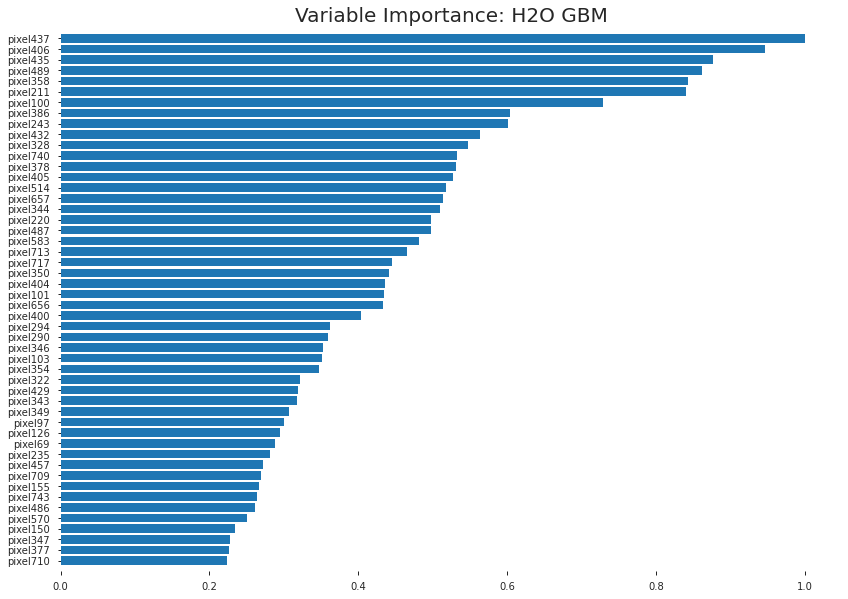

In [24]:
#If you want to choose a model other than the first one on the list. Choose the position number:
posicao_melhor_modelo=0

melhor_modelo = h2o.load_model('%s/models/todos/%s' % (OutputPath, modelos_testados.iloc[posicao_melhor_modelo, 0]))
(print("\n"+ "BEST MODEL: " + str(modelos_testados.iloc[posicao_melhor_modelo, 0]) + "\n"))

plt.rcParams.update({'font.size': 10})
try:
    melhor_modelo.varimp_plot(50)
except Exception as e:
    print("Warning: This model doesn't have variable importances")

## 6.4 Stepwise for Analysis of the importance of variables

In [25]:
#Listar todas as variáveis do modelo atual, ordenadas por variable importance
#Para as variaveis definidas como fator (que possivelmente estão como dummys), remover a categoria do nome e deixar apenas o nome orifinal da variavel

#List all variables in the current model, ordered by variable importance
#For variables defined as a factor (which possibly are like dummys), remove the category from the name and leave only the orifinal name of the variable
try:
    df_features_sorted = melhor_modelo.varimp(True).variable.str.split('.', expand=True).drop_duplicates(subset = 0)[0].reset_index(drop=True)
except Exception as e:
    #As the model with ensemble in H20 does not show the importance of variables, we will include variables with higher IV first using result_formatado graph of step 5.1
    df_features_sorted = result_formated_graph.Variable.reset_index(drop=True)

In [26]:
#Define the number of variables to be increased with each new model. Try to put 10% or 20% of the total, as it can take a long time
qt_var=10
qt_total_var = len(df_features_sorted)

dict_model_tmp={}
dict_performance={}

for i in range(qt_var, qt_total_var+qt_var, qt_var):    
    df_features_sorted[0:i].values.tolist()    
    
    #If no model chosen is not an ensemble of models. Then use the same model for training with increment of variables
    melhor_modelo_tmp = melhor_modelo
    if melhor_modelo_tmp.model_id.lower().find("ensemble") == -1:
        dict_model_tmp[i] = melhor_modelo_tmp
        dict_model_tmp[i].train(x = df_features_sorted[0:i].values.tolist(),
                                y = var_target,
                                training_frame=train_hdf, 
                                validation_frame=valid_hdf)
    ##If it is not possible, for the home of an ensemble of models, use GradientBoostingEstimator to make the assessment
    else:
        dict_model_tmp[i] = H2OGradientBoostingEstimator(seed=1, model_id=str('model_tmp_%s' % i))
        dict_model_tmp[i].train(x = df_features_sorted[0:i].values.tolist(),
                                y = var_target,
                                training_frame=train_hdf, 
                                validation_frame=valid_hdf)       


    perform_oot = dict_model_tmp[i].model_performance(test_hdf)
    dict_performance_tmp = {}
    dict_performance_tmp['MSE'] = {'qt_var': i, 'medida': 'MSE', 'Validation_Dataset': dict_model_tmp[i].mse(valid=True), 'Test_Dataset': perform_oot.mse()}
    dict_performance_tmp['RMSE'] = {'qt_var': i, 'medida': 'RMSE', 'Validation_Dataset': dict_model_tmp[i].rmse(valid=True), 'Test_Dataset': perform_oot.rmse()}
    dict_performance_tmp['logloss'] = {'qt_var': i, 'medida': 'logloss', 'Validation_Dataset': dict_model_tmp[i].logloss(valid=True), 'Test_Dataset': perform_oot.logloss()}
    dict_performance[i] = pd.DataFrame(dict_performance_tmp).transpose()

gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |███████████████████████████████████████████████| 100%
gbm Model Build progress: |█

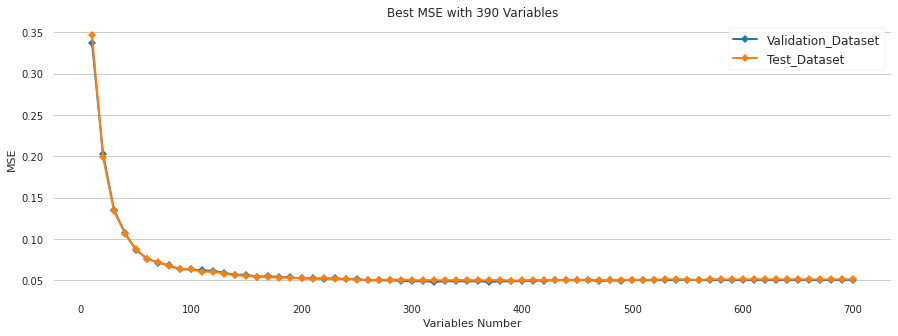

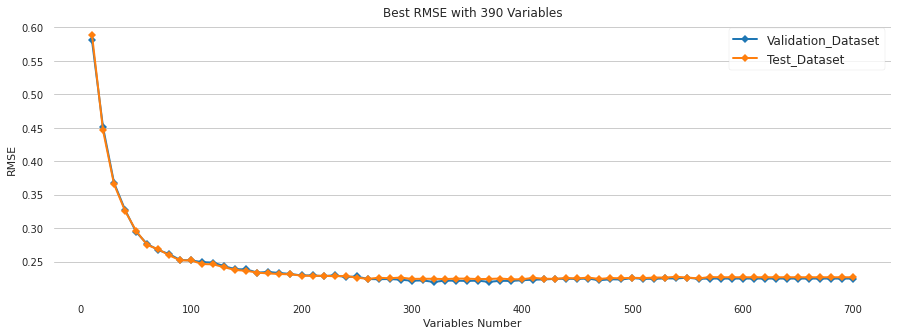

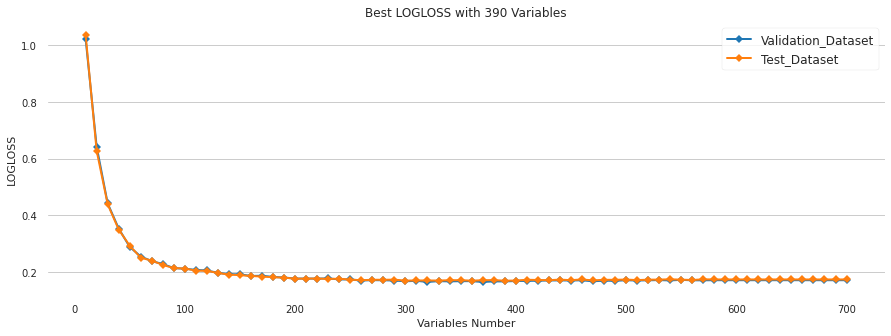

In [27]:
##Plot graph comparing the increase in performance with the increase in variables
for i in dict_performance.keys():
    if i == list(dict_performance.keys())[0]:
        df_performance = dict_performance[i]
    else:
        df_performance = df_performance.append(dict_performance[i], ignore_index=True)

lista_metricas_perf = df_performance['medida'].unique()

for i in range(len(lista_metricas_perf)):   
    #selects only the metric to be analyzed
    metrics_df_tmp = df_performance.query('medida == "%s"' % lista_metricas_perf[i])
    metrics_df_tmp = metrics_df_tmp.set_index('qt_var')
    del metrics_df_tmp['medida']
    if lista_metricas_perf[i] == 'R2':
        max_oot = metrics_df_tmp[metrics_df_tmp['Test_Dataset'] == metrics_df_tmp.Test_Dataset.max()].index.values
    else:
        max_oot = metrics_df_tmp[metrics_df_tmp['Test_Dataset'] == metrics_df_tmp.Test_Dataset.min()].index.values
        
    if lista_metricas_perf[i] == 'logloss':
        max_oot_filtro = max_oot[0]        
    
    ax=metrics_df_tmp.plot(figsize=(15,5), linewidth=2, fontsize=10, marker='D', ms=5,\
                            title='Best %s with %s Variables' % (lista_metricas_perf[i].upper(), str(max_oot[0])))
    plt.xlabel('Variables Number')
    plt.ylabel('%s' % lista_metricas_perf[i].upper())
    plt.grid(axis='y')
    plt.legend(loc=0, prop={'size': 12})
    #display(ax)

In [28]:
print('Consider removing the following variables: '+ str(df_features_sorted[df_features_sorted.index > int(max_oot_filtro)].values.tolist()))

Consider removing the following variables: ['pixel480', 'pixel341', 'pixel620', 'pixel495', 'pixel134', 'pixel332', 'pixel474', 'pixel678', 'pixel610', 'pixel389', 'pixel390', 'pixel497', 'pixel129', 'pixel632', 'pixel498', 'pixel679', 'pixel547', 'pixel692', 'pixel716', 'pixel501', 'pixel122', 'pixel201', 'pixel200', 'pixel555', 'pixel634', 'pixel157', 'pixel412', 'pixel257', 'pixel259', 'pixel443', 'pixel493', 'pixel595', 'pixel649', 'pixel635', 'pixel479', 'pixel693', 'pixel133', 'pixel305', 'pixel660', 'pixel581', 'pixel203', 'pixel286', 'pixel361', 'pixel102', 'pixel71', 'pixel689', 'pixel680', 'pixel160', 'pixel605', 'pixel135', 'pixel579', 'pixel385', 'pixel158', 'pixel650', 'pixel607', 'pixel227', 'pixel417', 'pixel314', 'pixel287', 'pixel340', 'pixel246', 'pixel537', 'pixel312', 'pixel556', 'pixel694', 'pixel553', 'pixel453', 'pixel675', 'pixel648', 'pixel500', 'pixel482', 'pixel667', 'pixel395', 'pixel623', 'pixel70', 'pixel284', 'pixel368', 'pixel108', 'pixel593', 'pixel256'

## 6.5 Exporting the best model to Deploy

In [29]:
#Save the H2O model in MOJO format and all the variables of the best model
melhor_modelo = h2o.load_model('%s/models/todos/%s' % (OutputPath, modelos_testados.iloc[posicao_melhor_modelo, 0]))
caminho_modelo_mojo = melhor_modelo.download_mojo('%s/models/melhores/' % OutputPath, get_genmodel_jar=True)
print(caminho_modelo_mojo)
caminho_modelo_h2o = h2o.save_model(model=melhor_modelo, path='%s/models/melhores/' % OutputPath, force=True)

/kaggle/temp/models/melhores/GBM_digit_recognizer_FML_v120210403_145502.zip


In [30]:
try:
    features_names= melhor_modelo.varimp(True)
    features_names.to_csv('%s/models/melhores/features_names_%s.csv' % (OutputPath, melhor_modelo.model_id), sep=';')
except Exception as e:
    print("Warning: This model doesn't have variable importances")

# 7. Predict Submision dataset using MOJO or H2O Model

In [31]:
submission_df = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

submission_df = submission_df.astype('float32')
submission_df = submission_df / 255

#Numeric features must be float type
for col_name in NUM:    
    submission_df[col_name] = submission_df[col_name].astype(float)    

#Categorical features must be string type and null values will be filled with "missing"
for col_name in CAT:        
    submission_df[col_name] = submission_df[col_name].astype(str)    
    submission_df = submission_df.fillna(value={col_name: 'missing'}) 

In [32]:
#Importar MOJO
try:
    test_tmp = h2o.mojo_predict_pandas(submission_df, caminho_modelo_mojo)    
    predict_df = submission_df.merge(test_tmp, left_index=True, right_index=True)
except:    
    submission_hdf = h2o.H2OFrame(submission_df)
    for col_name in CAT:
        submission_hdf[col_name] = submission_hdf[col_name].asfactor() 
    h2o_predict = melhor_modelo.predict(submission_hdf)
    predict_df = h2o_predict.cbind(submission_hdf).as_data_frame()
    
predict_df.rename(columns={'predict':'Label'}, inplace=True)
predict_df = predict_df.reset_index(drop=True)
predict_df = predict_df.reset_index(drop=False)
predict_df.rename(columns={'index':'ImageId'}, inplace=True)
predict_df['ImageId'] = predict_df['ImageId']+1
predict_df.loc[:, ('ImageId', 'Label')]

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


# 8. Save final dataset with predictions

In [33]:
predict_df.loc[:, ('ImageId', 'Label')].to_csv('/kaggle/working/digit_recognizer_submission.csv', index=False)

## END